In [31]:
# Studying how well we can perform the surface code when some shuttling channels
# are broken

# For paper: note that there are more intelligent ways you could deal with the
# higher-dropout cases (like changing data qubit placement). In principle, could
# tolerate very high dropout rates, as long as you can find large enough
# reachable regions

In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import pickle
import sinter
from copy import deepcopy
import scipy
import signal

import src.device as device
import src.plotting as plotter
import src.stim_dag as stim_dag

from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.TileCode import TileCode
from src.HGPCode import HGPCode
from src.SHYPSCode import SHYPSCode
from src.RadialCode import RadialCode
from src.GBCode import GBCode
from src.HypercubeCode import HypercubeCode
from src.decoders import BPOSD
from src.constructor import construct_code

In [8]:
with open('notebooks/data/16_dropouts.pkl', 'rb') as f:
    data = pickle.load(f)
    ds = data['ds']
    schedule_lengths_baseline = data['schedule_lengths_baseline']
    schedule_lengths = data['schedule_lengths']
    trials = data['trials']
    dropout_rates = data['dropout_rates']

schedule_lengths = schedule_lengths[:, :, 0]

0.0001 0
0.00010174634027476064 0
0.00010352317759307388 0
0.00010533104453709371 0
0.00010717048298967114 0
0.00010904204429677526 0
0.00011094628943275218 0
0.00011288378916846895 0
0.0001148551242423938 0
0.00011686088553466509 0
0.00011890167424419898 0
0.00012097810206889013 0
0.00012309079138896018 0
0.00012524037545350733 0
0.00012742749857031334 0
0.00012965281629896688 0
0.00013191699564735717 0
0.0001342207152716012 0
0.00013656466567946111 0
0.00013894954943731373 0
0.00014137608138073613 0
0.0001438449888287663 0
0.00014635701180190798 0
0.00014891290324394103 0
0.0001515134292476053 0
0.00015415936928422718 0
0.00015685151643735477 0
0.0001595906776404731 0
0.0001623776739188721 0
0.000165213340635737 0
0.00016809852774253637 0
0.00017103410003378413 0
0.00017402093740624848 0
0.0001770599351226898 0
0.00018015200408020256 0
0.00018329807108324357 0
0.0001864990791214298 0
0.00018975598765218503 0
0.00019306977288832496 0
0.00019644142809066285 0
0.00019987196386572507 0
0

/home/jchadwick/projects/shuttle-ldpc/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jchadwick/projects/shuttle-ldpc/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/jchadwick/projects/shuttle-ldpc/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jchadwick/projects/shuttle-ldpc/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/jchadwick/projects/shuttle-ldpc/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret 

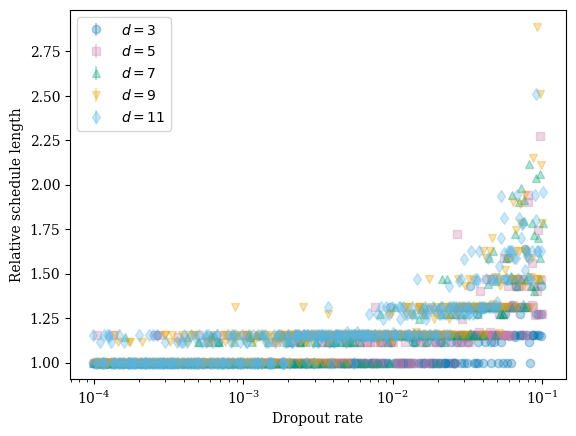

In [9]:
markers = ['o', 's', '^', 'v', 'd']

for d_i,d in enumerate(ds):
    ydata = []
    yerr = []
    for dropout_rate, sched_lens in zip(dropout_rates, schedule_lengths[d_i]):
        scheds_ok = sched_lens[sched_lens < 10**10]
        num_none = np.count_nonzero(sched_lens >= 10**10)
        print(dropout_rate, num_none)
        avg_len = np.mean(scheds_ok)
        std_len = np.std(scheds_ok)
        ydata.append(avg_len / schedule_lengths_baseline[d_i])
        if len(scheds_ok) > 1:
            yerr.append(2*std_len / schedule_lengths_baseline[d_i])
        else:
            yerr.append(0)
    plt.errorbar(dropout_rates*(1 + 0.05*(np.random.random(len(dropout_rates))-0.5)), ydata, yerr=yerr, color=f'C{d_i}', marker=markers[d_i], label=r'$d=' + f'{d}' + r'$', linestyle='none', alpha=0.3)
plt.xscale('log')
plt.legend()
plt.xlabel('Dropout rate')
plt.ylabel('Relative schedule length')
plt.show()

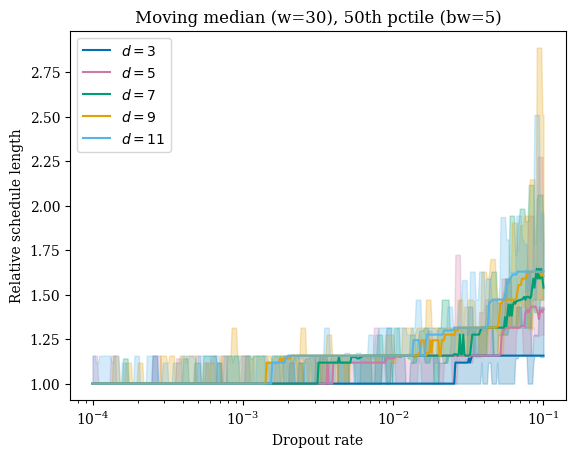

In [ ]:

# ---- smoothing options ----
smooth_method  = 'median'    # 'mean' or 'median'
band_method    = 'percentile'       # 'std' or 'percentile'
band_param     = 50         # multiplier for std, or half-width percentile (e.g. 25 → [25,75])
window         = 30          # smoothing window for center line
band_window    = 1           # smoothing window for band (None → per-point, i.e. no window)
# --------------------------

def smooth_and_band(values_per_rate, baseline, window, smooth_method, band_method, band_param, band_window=None):
    """
    values_per_rate : list of 1-D arrays (one per dropout rate), possibly containing inf sentinels
    Returns centers, lows, highs – all relative to baseline.
    band_window: window size for band computation. None means per-point (window=1).
    """
    n = len(values_per_rate)
    centers = np.full(n, np.nan)
    lows    = np.full(n, np.nan)
    highs   = np.full(n, np.nan)
    bw = 1 if band_window is None else band_window

    for i in range(n):
        # windowed center
        i0, i1 = max(0, i - window // 2), min(n, i + window // 2 + 1)
        window_vals = np.concatenate([
            v[v < 10**10] for v in values_per_rate[i0:i1]
        ])
        if len(window_vals) > 0:
            rel = window_vals / baseline
            centers[i] = np.mean(rel) if smooth_method == 'mean' else np.median(rel)

        # band with its own (possibly smaller) window
        b0, b1 = max(0, i - bw // 2), min(n, i + bw // 2 + 1)
        band_vals = np.concatenate([
            v[v < 10**10] for v in values_per_rate[b0:b1]
        ])
        if len(band_vals) == 0:
            continue
        rel_b = band_vals / baseline
        if band_method == 'std':
            s = np.std(rel_b)
            c = np.mean(rel_b) if smooth_method == 'mean' else np.median(rel_b)
            lows[i]  = c - band_param * s
            highs[i] = c + band_param * s
        else:  # percentile
            lows[i]  = np.percentile(rel_b, 50 - band_param)
            highs[i] = np.percentile(rel_b, 50 + band_param)

    return centers, lows, highs


fig, ax = plt.subplots()
markers = ['o', 's', '^', 'v', 'd']
xs_all = np.asarray(dropout_rates)

for d_i, d in enumerate(ds):
    centers, lows, highs = smooth_and_band(
        schedule_lengths[d_i],
        schedule_lengths_baseline[d_i],
        window, smooth_method, band_method, band_param,
        band_window=band_window,
    )
    color = f'C{d_i}'
    label = r'$d=' + f'{d}' + r'$'
    mask = np.isfinite(centers)
    xs = xs_all[mask]

    ax.plot(xs, centers[mask], color=color, label=label)
    bmask = np.isfinite(lows) & np.isfinite(highs)
    ax.fill_between(xs_all[bmask], lows[bmask], highs[bmask], color=color, alpha=0.25)

ax.set_xscale('log')
ax.legend()
ax.set_xlabel('Dropout rate')
ax.set_ylabel('Relative schedule length')
bw_str = f'bw={band_window}' if band_window is not None else 'per-point'
method_str = f'{smooth_method} (w={window}), {band_param}{"×std" if band_method=="std" else "th pctile"} ({bw_str})'
ax.set_title(f'Moving {method_str}')
plt.show()
